In [2]:
# PART A — Sales Forecast (Decision Making)
import pandas as pd
from sklearn.linear_model import LinearRegression

# Sales Data
data = {
    "Month": [1,2,3,4,5,6],
    "Sales": [2000,2500,3000,3500,4000,4500]
}

df = pd.DataFrame(data)

X = df[["Month"]]
y = df["Sales"]

model = LinearRegression()
model.fit(X,y)

prediction = model.predict([[7]])

print("Predicted Sales for Month 7:", int(prediction[0]))
# Explain (Khmer)
# AI រៀនពី Sales ចាស់
# → ទស្សន៍ទាយខែបន្ទាប់
# → ជួយម្ចាស់ហាងសម្រេចចិត្ត


Predicted Sales for Month 7: 5000


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [4]:
from sklearn.cluster import KMeans

data = {
    "PurchaseAmount":[100,200,1500,1800,120,1700]
}

df = pd.DataFrame(data)

model = KMeans(n_clusters=2)
df["Group"] = model.fit_predict(df)

print(df)
# Explain
# AI បែងចែកអតិថិជនជា:
# •	Low Spender
# •	High Spender
# → អាចផ្ញើ Promotion ខុសគ្នា


   PurchaseAmount  Group
0             100      1
1             200      1
2            1500      0
3            1800      0
4             120      1
5            1700      0


In [5]:
def chatbot():
    while True:
        user = input("Customer: ")
        
        if "price" in user.lower():
            print("Bot: Our product price is $10")
        elif "exit" in user.lower():
            print("Bot: Thank you!")
            break
        else:
            print("Bot: Please contact support.")

chatbot()
# Explain
# Bot ឆ្លើយសំណួរ 24/7
# → មិនចាំបាច់មានបុគ្គលិកជានិច្ច


Customer:  how this price?


Bot: Our product price is $10


Customer:  exit


Bot: Thank you!


In [ ]:
# AI Customer Purchase Prediction System (Business AI Project)

# គោលបំណងគម្រោង៖
# បង្កើត Machine Learning Model ដើម្បី Predict ថា Customer នឹងទិញ Product ឬអត់ ដើម្បីជួយ Business ក្នុង

# Automation

# Decision Making

# Marketing Strategy

# 1. Project Structure (Jupyter Notebook)

# Notebook មាន Sections ខាងក្រោម

# 1. Introduction
# 2. Import Libraries
# 3. Generate Business Dataset
# 4. Data Exploration
# 5. Data Visualization
# 6. Data Preparation
# 7. Train Machine Learning Model
# 8. Model Evaluation
# 9. Cross Validation
# 10. Business Prediction System
# 11. Business Insights
# 12. Conclusion
# 2. Introduction (Markdown)

# នៅក្នុង Notebook សរសេរ

# # AI Customer Purchase Prediction System

# This project demonstrates how Artificial Intelligence can help businesses
# predict customer purchasing behavior.

# Business Benefits:
# - Automate customer analysis
# - Improve marketing targeting
# - Support business decision-making

# Machine Learning Algorithm:
# Logistic Regression

In [6]:
# 3. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [7]:
# 4. Generate Business Dataset

# ក្នុង Project ពិតប្រាកដ Data អាចមកពី

# CRM

# Website

# Sales System

# នៅទីនេះយើង Generate Data

np.random.seed(42)

data_size = 500

age = np.random.randint(18,60,data_size)
income = np.random.randint(1000,8000,data_size)
website_visits = np.random.randint(1,20,data_size)
time_on_site = np.random.randint(1,15,data_size)

purchase = (
    (income > 3500) &
    (website_visits > 8)
).astype(int)

df = pd.DataFrame({
    "Age":age,
    "Income":income,
    "WebsiteVisits":website_visits,
    "TimeOnSite":time_on_site,
    "Purchased":purchase
})

df.head()
# Purchased = តើ Customer បានទិញ Product ឬអត់
# វាជា Target Variable (Label) ដែល Machine Learning ត្រូវ Predict។

# Income មានន័យថា
# Income = ចំណូលរបស់ Customer ក្នុងមួយខែ
# ជាទូទៅវាជាចំនួនលុយដែល Customer រកបានពី
# Salary (ប្រាក់ខែ)
# Business (អាជីវកម្ម)
# Other income

# Why Income Important for AI?
# ក្នុង Business
# Income មានឥទ្ធិពលទៅលើ Purchasing Power
# Income High → More chance to buy
# Income Low → Less chance to buy

# WebsiteVisits មានន័យថា
# WebsiteVisits = ចំនួនដងដែល Customer ចូលទៅមើល Website
# ជាធម្មតា គេវាស់ក្នុង
# 1 day
# 1 week
# 1 month
# ក្នុង Dataset នេះយើងសន្មត់ថា
# WebsiteVisits = Number of times a customer visits the website

,Age,Income,WebsiteVisits,TimeOnSite,Purchased
0,56,5132,11,9,1
1,46,4851,8,3,0
2,32,4440,19,4,1
3,25,4766,13,10,1
4,38,6644,12,1,1


In [8]:
# 5. Data Exploration
df.info()
df.describe()
df["Purchased"].value_counts()

# អត្ថន័យ

# Purchased = 1 → Customer ទិញ

# Purchased = 0 → មិនទិញ



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Age            500 non-null    int64
 1   Income         500 non-null    int64
 2   WebsiteVisits  500 non-null    int64
 3   TimeOnSite     500 non-null    int64
 4   Purchased      500 non-null    int64
dtypes: int64(5)
memory usage: 19.7 KB


Purchased
0    311
1    189
Name: count, dtype: int64

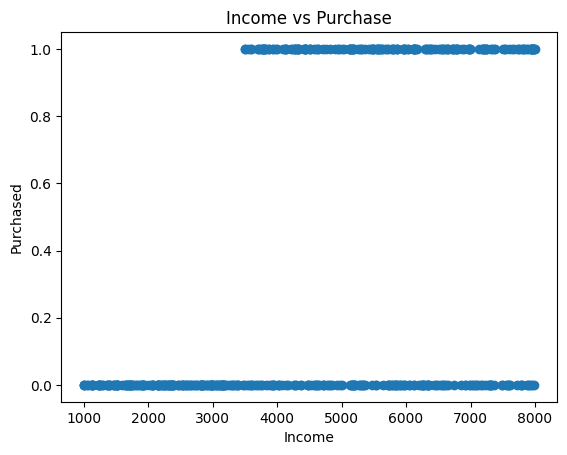

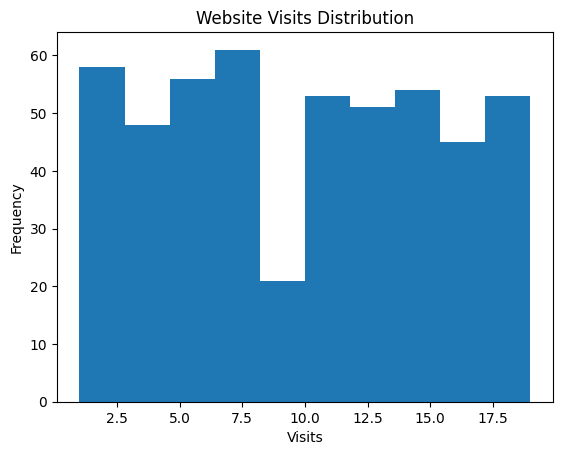

In [10]:
# 6. Data Visualization
# Customer Income vs Purchase
plt.scatter(df["Income"],df["Purchased"])
plt.xlabel("Income")
plt.ylabel("Purchased")
plt.title("Income vs Purchase")
plt.show()
# Website Visits Distribution
plt.hist(df["WebsiteVisits"])
plt.title("Website Visits Distribution")
plt.xlabel("Visits")
plt.ylabel("Frequency")
plt.show()

# Visualization ជួយ Business យល់

# Customer behavior

# Buying patterns



In [11]:
# 7. Data Preparation

# Feature Selection

X = df[["Age","Income","WebsiteVisits","TimeOnSite"]]

y = df["Purchased"]

# Split Dataset

X_train,X_test,y_train,y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)


In [16]:
# 8. Train Machine Learning Model

# យើងប្រើ Logistic Regression

# ព្រោះ

# Classification Problem

# Predict Yes / No

model = LogisticRegression()

model.fit(X_train,y_train)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [13]:
# 9. Model Prediction
y_pred = model.predict(X_test)
# 10. Model Evaluation
# Accuracy
accuracy = accuracy_score(y_test,y_pred)

print("Model Accuracy:",accuracy)
# Confusion Matrix
cm = confusion_matrix(y_test,y_pred)

print(cm)

# Meaning

# True Positive
# True Negative
# False Positive
# False Negative
# Classification Report
# print(classification_report(y_test,y_pred))

# Metrics

# Precision

# Recall

# F1-score
# ក្នុង Machine Learning (Classification) ពេលយើងវាយតម្លៃ Model យើងប្រើ Confusion Matrix ដែលមាន 4 លទ្ធផលសំខាន់ៗ៖
#                  Actual (ពិតប្រាកដ)
#                 Yes        No
# Prediction  -------------------------
# Yes           TP         FP
# No            FN         TN
# 1️⃣ True Positive (TP)
# Meaning:
# Model Predict ថា Yes ហើយ Actual ក៏ Yes
# 👉 Model ទាយត្រូវ
# Example
# AI Predict
# Customer will buy = Yes
# Actual
# Customer actually buys
# ✅ Correct prediction
# 2️⃣ True Negative (TN)
# Meaning:
# Model Predict ថា No ហើយ Actual ក៏ No
# 👉 Model ទាយត្រូវ
# Example
# AI Predict
# Customer will not buy
# Actual
# Customer really did not buy
# ✅ Correct prediction
# 3️⃣ False Positive (FP)
# Meaning:
# Model Predict ថា Yes ប៉ុន្តែ Actual = No
# 👉 Model ទាយខុស
# Example
# AI Predict
# Customer will buy
# Actual
# Customer did NOT buy
# ❌ Model mistake
# Business Impact
# Send promotion but customer not buy
# 4️⃣ False Negative (FN)
# Meaning:
# Model Predict ថា No ប៉ុន្តែ Actual = Yes
# 👉 Model ទាយខុស
# Example
# AI Predict
# Customer will NOT buy
# Actual
# Customer actually buy
# ❌ Model mistake
# Business Impact
# Miss potential customer

Model Accuracy: 0.9
[[56  6]
 [ 4 34]]


In [14]:
# 11. Cross Validation (Prevent Overfitting)
scores = cross_val_score(model,X,y,cv=5)

print("Cross Validation Scores:",scores)

print("Average Score:",scores.mean())

# នេះជាអ្វីដែល LLO6 និយាយអំពី

# Model evaluation

# Prevent overfitting



Cross Validation Scores: [0.87 0.77 0.89 0.93 0.88]
Average Score: 0.8680000000000001


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also 

In [15]:
# 12. Business Prediction System

# Example Customer

new_customer = [[30,4500,12,10]]

prediction = model.predict(new_customer)

print(prediction)

# Result

# 1 = Customer will buy
# 0 = Customer will not buy


[0]


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [ ]:
# 13. Business Decision Example

# AI System អាចជួយ

# If prediction = 1
# → Send promotion
# → Recommend product

# If prediction = 0
# → Show advertisement
# → Send discount coupon

# នេះហៅថា

# AI-driven Marketing

# 14. Business Insight Analysis

# Example Insights

# Customers with income > 3500
# and website visits > 8
# are more likely to purchase.

# Marketing team should target this group.
# 15. Real-World Applications

# AI System ដូចនេះប្រើនៅ

# E-commerce

# Amazon
# Alibaba
# Shopify

# Banking

# Credit card prediction
# Loan approval
# Fraud detection

# Marketing

# Customer segmentation
# Recommendation system
# 16. Conclusion

# Project នេះបង្ហាញថា AI អាចជួយ Business

# 1️⃣ Automate customer analysis
# 2️⃣ Predict customer behavior
# 3️⃣ Improve marketing strategies
# 4️⃣ Support business decision making

# នេះគឺជា Real-world AI Application

# ដែលគាំទ្រ LLO3 – AI Transforming Business